In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

np.random.seed(42)

human_top1 = pd.read_csv("results/top1/human_title_summary_preds.csv")
mouse_top1 = pd.read_csv("results/top1/mouse_title_summary_preds.csv")

cancer_terms = set(pd.read_csv("data/cancer_terms.csv")["mondo_id"])
edges_df = pd.read_csv("data/cancer_model_edges.csv")

ROOT = "MONDO_0004992"

parents = defaultdict(set)
children = defaultdict(set)

for _, row in edges_df.iterrows():
    child = row["child"]
    parent = row["parent"]
    if child in cancer_terms and parent in cancer_terms:
        parents[child].add(parent)
        children[parent].add(child)

depth = {ROOT: 0}
queue = deque([ROOT])

while queue:
    current = queue.popleft()
    for ch in children.get(current, []):
        if ch not in depth:
            depth[ch] = depth[current] + 1
            queue.append(ch)


def ancestors_with_depth(term):
    out = {}
    q = deque([(term, 0)])
    visited = {term}
    while q:
        node, dist = q.popleft()
        for p in parents.get(node, set()):
            if p not in visited:
                visited.add(p)
                out[p] = dist + 1
                q.append((p, dist + 1))
    return out

def lca_depth(term1, term2):
    anc1 = set(ancestors_with_depth(term1).keys()) | {term1}
    anc2 = set(ancestors_with_depth(term2).keys()) | {term2}
    common = anc1 & anc2
    if not common:
        return np.nan
    return max(depth.get(x, -1) for x in common)

def tree_distance(term1, term2):
    d1 = depth.get(term1, np.nan)
    d2 = depth.get(term2, np.nan)
    lca_d = lca_depth(term1, term2)
    if pd.isna(d1) or pd.isna(d2) or pd.isna(lca_d):
        return np.nan
    return d1 + d2 - 2 * lca_d

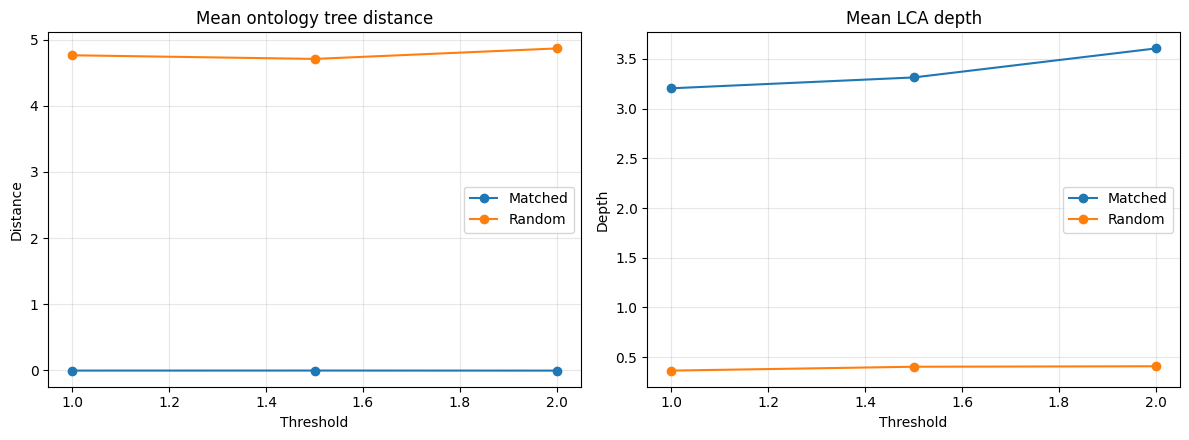

Saved threshold sensitivity summary.


In [2]:
def evaluate_threshold(thresh):
    human = human_top1[
        (human_top1["log2(prob/prior)"] > thresh) &
        (human_top1["mondo_id"].isin(cancer_terms))
    ].copy()

    mouse = mouse_top1[
        (mouse_top1["log2(prob/prior)"] > thresh) &
        (mouse_top1["mondo_id"].isin(cancer_terms))
    ].copy()

    matched = human.merge(mouse, on="mondo_id", suffixes=("_human", "_mouse"))

    n_random = len(matched)
    if n_random == 0:
        return pd.DataFrame([{
            "threshold": thresh,
            "n_human": len(human),
            "n_mouse": len(mouse),
            "n_matched": 0,
            "matched_mean_tree_distance": np.nan,
            "random_mean_tree_distance": np.nan,
            "matched_mean_lca_depth": np.nan,
            "random_mean_lca_depth": np.nan
        }])

    human_idx = np.random.choice(human.index, size=n_random, replace=True)
    mouse_idx = np.random.choice(mouse.index, size=n_random, replace=True)

    random_pairs = pd.DataFrame({
        "mondo_id_human": human.loc[human_idx, "mondo_id"].values,
        "mondo_id_mouse": mouse.loc[mouse_idx, "mondo_id"].values
    })

    matched_pairs = pd.DataFrame({
        "mondo_id_human": matched["mondo_id"].values,
        "mondo_id_mouse": matched["mondo_id"].values
    })

    matched_pairs["tree_distance"] = [
        tree_distance(a, b)
        for a, b in zip(matched_pairs["mondo_id_human"], matched_pairs["mondo_id_mouse"])
    ]
    matched_pairs["lca_depth"] = [
        lca_depth(a, b)
        for a, b in zip(matched_pairs["mondo_id_human"], matched_pairs["mondo_id_mouse"])
    ]

    random_pairs["tree_distance"] = [
        tree_distance(a, b)
        for a, b in zip(random_pairs["mondo_id_human"], random_pairs["mondo_id_mouse"])
    ]
    random_pairs["lca_depth"] = [
        lca_depth(a, b)
        for a, b in zip(random_pairs["mondo_id_human"], random_pairs["mondo_id_mouse"])
    ]

    return pd.DataFrame([{
        "threshold": thresh,
        "n_human": len(human),
        "n_mouse": len(mouse),
        "n_matched": len(matched_pairs),
        "matched_mean_tree_distance": matched_pairs["tree_distance"].mean(),
        "random_mean_tree_distance": random_pairs["tree_distance"].mean(),
        "matched_mean_lca_depth": matched_pairs["lca_depth"].mean(),
        "random_mean_lca_depth": random_pairs["lca_depth"].mean()
    }])

summary = pd.concat(
    [evaluate_threshold(t) for t in [1.0, 1.5, 2.0]],
    ignore_index=True
)

summary

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax1, ax2 = axes

ax1.plot(summary["threshold"], summary["matched_mean_tree_distance"], marker="o", label="Matched")
ax1.plot(summary["threshold"], summary["random_mean_tree_distance"], marker="o", label="Random")
ax1.set_title("Mean ontology tree distance")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Distance")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(summary["threshold"], summary["matched_mean_lca_depth"], marker="o", label="Matched")
ax2.plot(summary["threshold"], summary["random_mean_lca_depth"], marker="o", label="Random")
ax2.set_title("Mean LCA depth")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Depth")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

summary.to_csv("results/ontology_distance_threshold_sensitivity.csv", index=False)
print("Saved threshold sensitivity summary.")